# Introduction to Machine Learning -- MC886
# Assignment 3 - Neural Networks and Overparameterization

**Professor:** Marcelo da Silva Reis  
**PED:** Daniel Gardin Gratti  
**PAD:** Guilherme Henrique Ichiro Seto Ito

In [32]:
# Enter your name and RA number below.
print("Caio Azevedo Dal Porto", "256709")
print("Vinicius Leme Soares", "260727")
print("Lucas Baptista", "202071")

Caio Azevedo Dal Porto 256709
Vinicius Leme Soares 260727
Lucas Baptista 202071


---

## Objective

In Assignment 2 you observed that neural networks can achieve low in-distribution error while failing under distribution shift. This overfitting scenario arises when the model exploits properties present in the training distribution that do not reflect the properties in the underlying data-generating process.

In this assignment, we study how architectural choices and overparameterization interact with inductive bias under distribution shift. In highly parameterized models, multiple distinct mechanisms can explain similar training performance, making it difficult to identify which assumptions about the data are actually responsible for generalization behavior.

For example, a classifier trained on histopathology images may achieve near-perfect training accuracy by either learning morphological features that are stable across imaging sites, or by relying on spurious correlations such as stain-color distributions that coincidentally align with class labels in the training hospitals.
Both solutions fit the training set equally well, but they encode different assumptions about which aspects of the input are relevant, leading to divergent behavior when these correlations are altered or removed in the test distribution.

The goal is to evaluate neural networks as hypothesis classes with different structural assumptions.

### Guidelines

> Please read these guidelines carefully.

1. Answers can be written in English or Portuguese.

2. Use data visualization as a primary tool for understanding. Inspect training data, corrupted inputs, and model behavior. When an assumption is uncertain, verify it empirically through plots.

3. The provided code serves as a reference. Modifications are allowed, including changes to functions and the introduction of new components. Code clarity and organization are required.

4. Use Google Colab or a GPU, if available, to speed up training.

5. The use of generative AI tools (e.g., ChatGPT, GitHub Copilot, DeepSeek, LLaMA) is permitted strictly for **implementation support**. Their use for interpreting, analyzing, or discussing experimental results is discouraged. Submissions must include:
   - A declaration of which models were used.
   - The prompts that generated any incorporated code.

6. Do not hesitate to reach out to the PED/PAD via Discord.

### Experiment structure

Each experiment must follow the structure below:

1. **Question**: the empirical question guiding the exploration.
2. **Hypothesis**: a falsifiable answer to the question that makes a concrete, measurable prediction.
3. **Design**: justify why the proposed experiment can test the hypothesis. Focus on the reasoning, not on how the code works.
4. **Results**: run the experiment and report the metrics.
5. **Discussion**: interpret the results in terms of the hypothesis. Explicitly state whether the results support or contradict it, and why.

A hypothesis must be **falsifiable**: the proposed experiment must be capable of providing evidence *against* it.
Statements such as "the model is complex enough" or "the features are informative" do not qualify.

A negative result is not a failure: a well-reasoned experiment that contradicts the hypothesis is graded as highly as one that confirms it, provided the interpretation is honest and coherent.

For Experiment 1, the question and hypothesis are given. Your task is to complete the missing code, write the design justification, and discuss the results.
For Experiments 2–4, only the question is given. You must state the hypothesis, justify the design, and discuss the results.

In [33]:
import numpy as np
import random

import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import TensorDataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.metrics import roc_auc_score

import matplotlib.pyplot as plt

# ── Reproducibility ────────────────────────────────────────────────────────────
# Do not change this seed. Re-run the notebook from scratch before submitting.
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

DEVICE: str = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: cpu


---

## Dataset — Camelyon17

Histopathology is usage of microscopes to study sections of tissues of an organism, often aiming to detect diseases. To this end, one technique involves the usage of oxylin and eosin (H&E)-stained tissue sections. Hematoxylin stains the cell's nucleus in purplish blue, while the eosin stains the cell's cytoplasm and extracellular matrix in pink. Therefore, the pathologist can differentiate structures in a histological section of a tissue.

Here, we will use [Camelyon17](https://camelyon17.grand-challenge.org/), a patch-level histopathology benchmark for tumor detection in H&E-stained lymph node sections. The task is binary classification: **normal tissue** (label 0) vs **tumor tissue** (label 1). Patches were extracted from Whole Slide Images (WSIs) acquired at **five different hospitals** (centers 0–4), each with its own scanner and staining protocol. These differences introduce systematic variation in color, texture, and brightness that is correlated with center identity rather than with tumor status.

**Experimental split:**

| Split | Centers | Role |
|-------|---------|------|
| Train | 0, 3, 4 | In-distribution training |
| Val (ID) | 1 | In-distribution validation — model selection |
| Test (OOD) | 2 | Out-of-distribution test — generalization evaluation |

![example image](https://wilds.stanford.edu/assets/images/dataset_figures/camelyon_dataset.jpg)

The OOD test set (center 2) uses a hospital that the model has never seen during training.
The **ID–OOD gap** in accuracy and AUC is the primary metric for evaluating generalization across all experiments.

The next cell is going to download the data using the [WILDS](https://wilds.stanford.edu/) library, which already
manage the data for us.
It may take a while to download the 10 Gb dataset in disk, but you only need to download it once.
You can also download it manually at https://worksheets.codalab.org/bundles/0xe45e15f39fb54e9d9e919556af67aabe

In [34]:
from wilds.datasets.camelyon17_dataset import Camelyon17Dataset
from wilds.common.data_loaders import get_train_loader

dataset = Camelyon17Dataset(root_dir="../data", download=False)

In [35]:
# IMPORTANT:
# The dataset is already split into "train", "val", and "test" subsets. Do not change the splits.
# The transform below will be applied to the images when we load them.
# These are the standard transforms used for the ResNet-18 model pretrained on ImageNet.
# (The parameters are the mean and standard deviation of the ImageNet dataset.)
# You can change the transforms if you want, but it is not required.

transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

# Set the fraction of data we will use (useful for making fast local tests)
fraction_to_use = 0.01


train_data = dataset.get_subset("train", transform=transform, frac=fraction_to_use)
val_data = dataset.get_subset("val", transform=transform, frac=fraction_to_use)
test_data = dataset.get_subset("test", transform=transform, frac=fraction_to_use)

print(f"Number of training samples: {len(train_data)}")
print(f"Number of validation samples: {len(val_data)}")
print(f"Number of test samples: {len(test_data)}")
print()
print(f"Hospital indices in training set: {torch.unique(train_data.metadata_array[:, 0])}")
print(f"Hospital indices in validation set: {torch.unique(val_data.metadata_array[:, 0])}")
print(f"Hospital indices in test set: {torch.unique(test_data.metadata_array[:, 0])}")

Number of training samples: 3024
Number of validation samples: 349
Number of test samples: 851

Hospital indices in training set: tensor([0, 3, 4])
Hospital indices in validation set: tensor([1])
Hospital indices in test set: tensor([2])


---

## Data Exploration

Before start working on the tasks, take a moment to explore the dataset and understand its structure.
Below, we simply observe the samples for each hospital in the training and validation sets.

The goal here is to have a better idea of what our task is, and what problems are already recognizable without
training any model.
Problems such as class imbalance, data invariances, what is the available information in the dataset, can be answered
here.

Conduct a data exploration step to understand what the data looks like, and then write your conclusions.

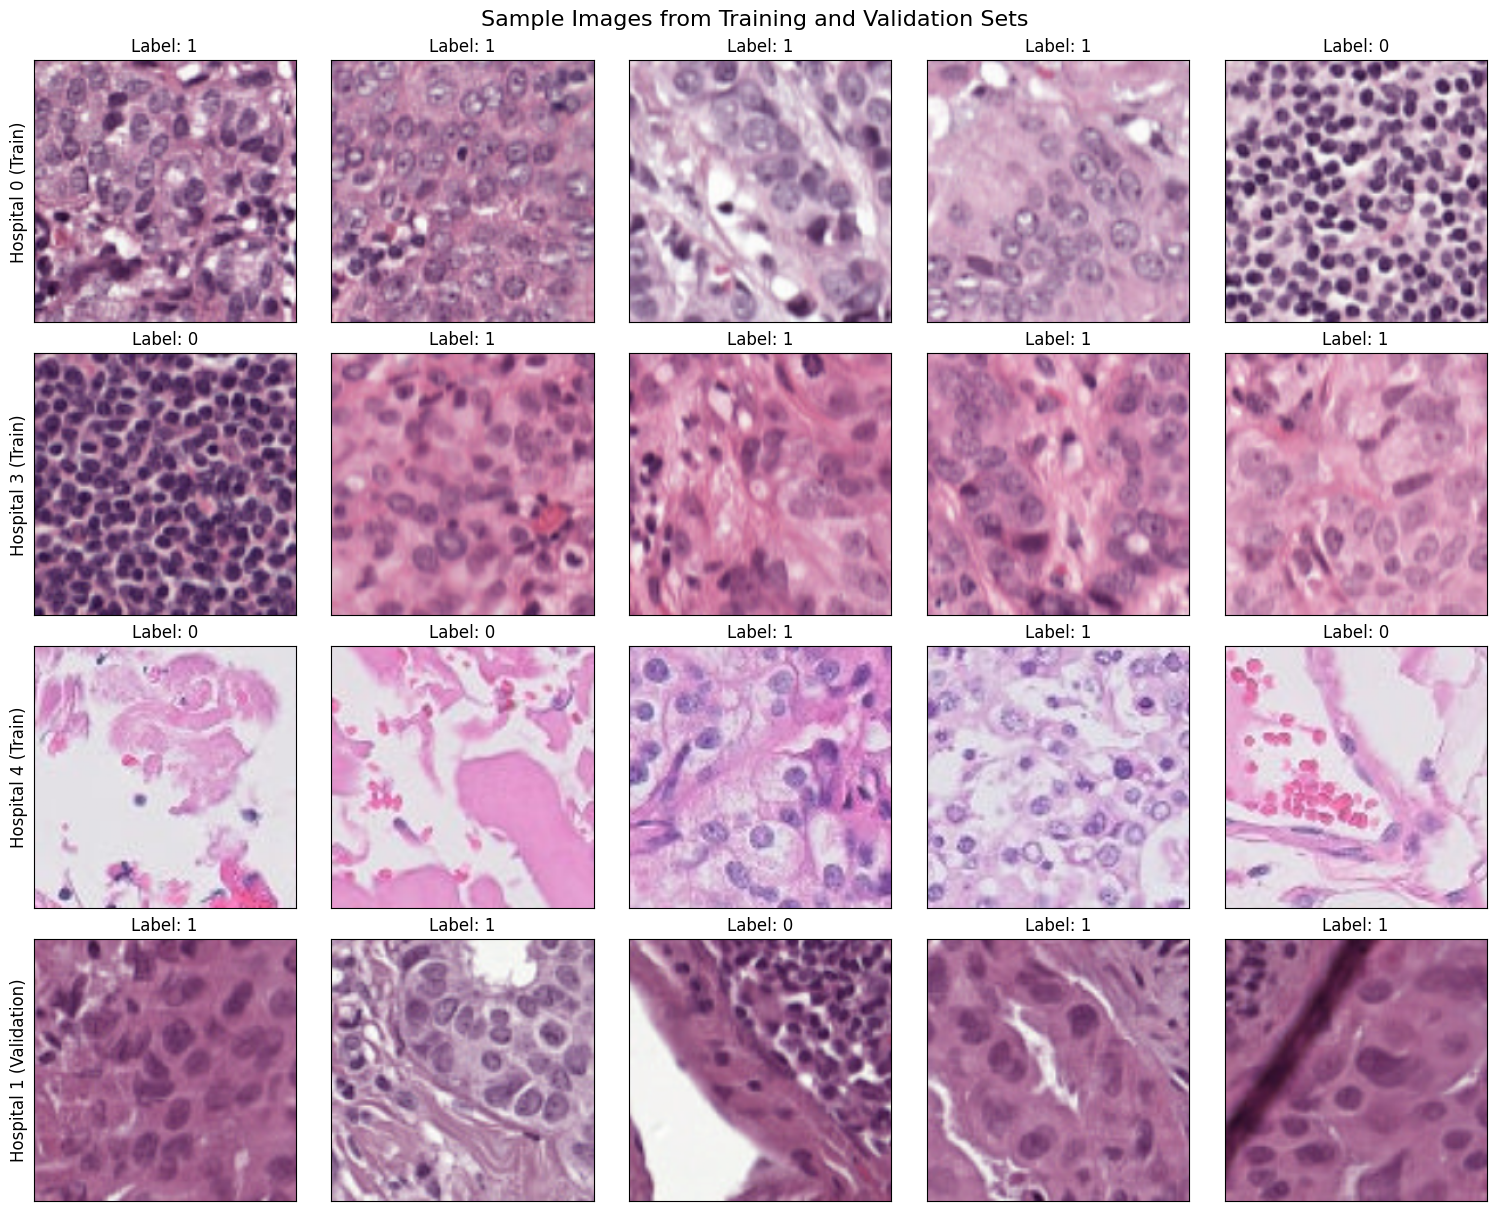

In [36]:
def denormalize(image: torch.Tensor) -> torch.Tensor:
    """Denormalizes an image tensor."""
    mean = torch.tensor([0.485, 0.456, 0.406], device=image.device).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=image.device).view(3, 1, 1)
    return (image * std + mean).permute(1, 2, 0)

n = 5

train_hospitals = torch.unique(train_data.metadata_array[:, 0])
val_hospitals = torch.unique(val_data.metadata_array[:, 0])

n_hospitals = len(train_hospitals) + len(val_hospitals)

fig, axes = plt.subplots(n_hospitals, n, figsize=(n * 3, n_hospitals * 3), constrained_layout=True)
for i, hospital in enumerate(train_hospitals):
    hospital_indices = torch.where(train_data.metadata_array[:, 0] == hospital)[0]
    selected_indices = np.random.choice(hospital_indices, n, replace=False)

    axes[i, 0].set_ylabel(f"Hospital {hospital.item()} (Train)", fontsize=12)

    for j, idx in enumerate(selected_indices):
        axes[i, j].set_yticks([])
        axes[i, j].set_xticks([])

        image, label, metadata= train_data[idx]
        axes[i, j].imshow(denormalize(image))  # Convert from (C, H, W) to (H, W, C)
        axes[i, j].set_title(f"Label: {label.item()}")

for i, hospital in enumerate(val_hospitals, start=len(train_hospitals)):
    hospital_indices = torch.where(val_data.metadata_array[:, 0] == hospital)[0]
    selected_indices = np.random.choice(hospital_indices, n, replace=False)

    axes[i, 0].set_ylabel(f"Hospital {hospital.item()} (Validation)", fontsize=12)

    for j, idx in enumerate(selected_indices):
        axes[i, j].set_yticks([])
        axes[i, j].set_xticks([])

        image, label, metadata= val_data[idx]
        axes[i, j].imshow(denormalize(image))
        axes[i, j].set_title(f"Label: {label.item()}")

fig.suptitle("Sample Images from Training and Validation Sets", fontsize=16)

plt.show()


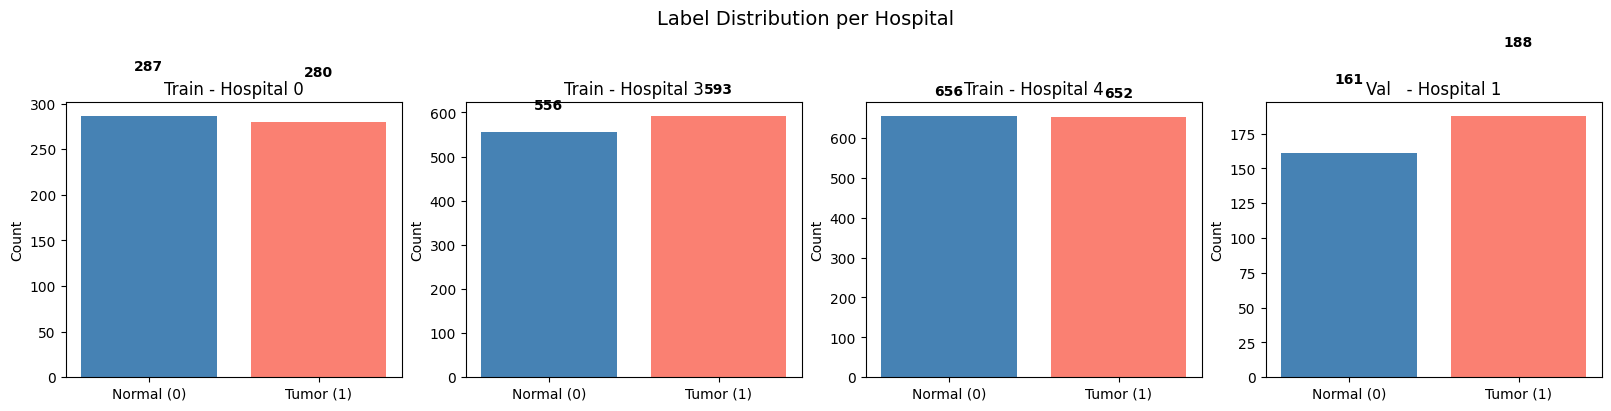

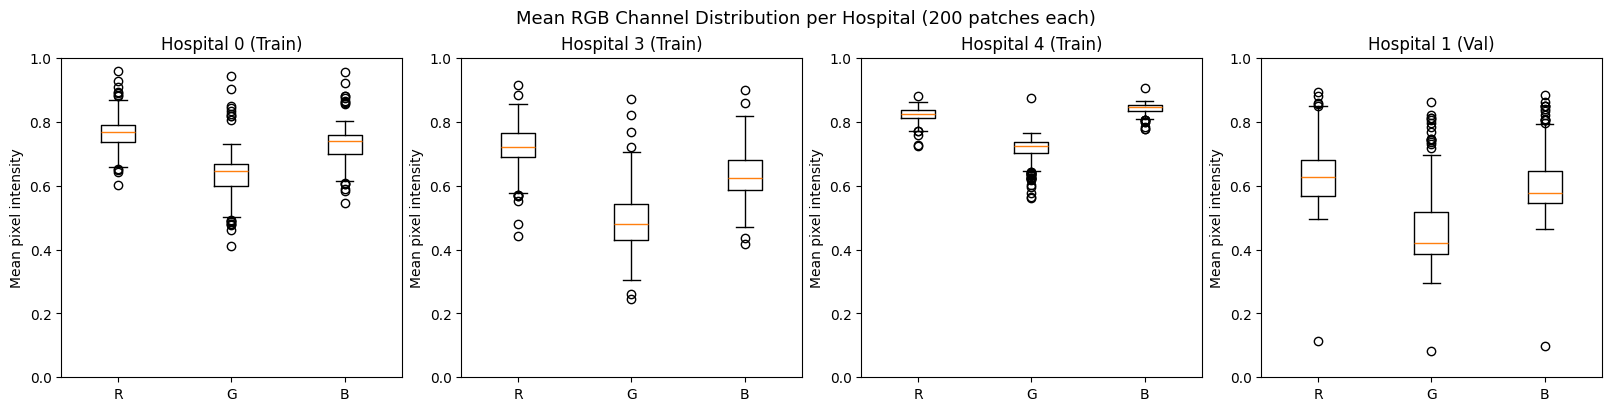

In [37]:
# Explore the dataset further, plot at least one more figure to compose your EDA.
# You can plot any figure you think will help you understand the dataset better. Examples include:
# - Distribution of labels across hospitals
# - Distribution of metadata features
# - Distribution of pixel intensities
# ── Additional EDA ────────────────────────────────────────────────────────────

# Label distribution per hospital
fig, axes = plt.subplots(1, 4, figsize=(16, 4), constrained_layout=True)

for i, (split_name, split_data) in enumerate([
    ('Train - Hospital 0', train_data),
    ('Train - Hospital 3', train_data),
    ('Train - Hospital 4', train_data),
    ('Val   - Hospital 1', val_data),
]):
    hosp_ids = [0, 3, 4, 1]
    ds = [train_data, train_data, train_data, val_data][i]
    mask = ds.metadata_array[:, 0] == hosp_ids[i]
    labels_hosp = ds.y_array[mask]
    counts = [(labels_hosp == 0).sum().item(), (labels_hosp == 1).sum().item()]
    axes[i].bar(['Normal (0)', 'Tumor (1)'], counts, color=['steelblue', 'salmon'])
    axes[i].set_title(split_name)
    axes[i].set_ylabel('Count')
    for j, v in enumerate(counts):
        axes[i].text(j, v + 50, f'{v}', ha='center', fontweight='bold')
fig.suptitle('Label Distribution per Hospital', fontsize=14)
plt.show()

# Mean RGB color per hospital (color shift visualization)
fig, axes = plt.subplots(1, 4, figsize=(16, 4), constrained_layout=True)
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

for i, (hosp_id, ds) in enumerate([(0, train_data), (3, train_data), (4, train_data), (1, val_data)]):
    mask = ds.metadata_array[:, 0] == hosp_id
    indices = torch.where(mask)[0][:200]  # sample 200 patches
    pixels = []
    for idx in indices:
        img, _, _ = ds[idx.item()]
        img_denorm = (img * std + mean).clamp(0, 1)  # (3, H, W)
        pixels.append(img_denorm.mean(dim=(1, 2)))  # mean per channel
    pixels = torch.stack(pixels)  # (N, 3)
    r, g, b = pixels[:, 0].numpy(), pixels[:, 1].numpy(), pixels[:, 2].numpy()
    axes[i].boxplot([r, g, b], tick_labels=['R', 'G', 'B'])
    split_label = 'Train' if ds is train_data else 'Val'
    axes[i].set_title(f'Hospital {hosp_id} ({split_label})')
    axes[i].set_ylabel('Mean pixel intensity')
    axes[i].set_ylim(0, 1)

fig.suptitle('Mean RGB Channel Distribution per Hospital (200 patches each)', fontsize=13)
plt.show()


> **Question.** (1.0 pts)
>
> What are your findings? Describe the task, the characteristics you have found, possible challenges that you will encounter, and other initial hypothesis.
>
> Do you think a neural network will be able to classify tumors and generalize to other hospitals?

Observando as imagens e os gráficos gerados, podemos notar inicialmente uma diferença de cor das imagens em relação ao hospital analisado, reforçado pela distribuição RGB. Vale também mencionar um possível ruído (borda de lâmina talvez) no dado do hospital 3.
Os patches com label 1 (tumor) aparentam ter núcleos mais densos e agrupados e com formas tamanhos mais irregulares, enquanto os tecidos com label 0 aparentam um aspecto mais esparso e uniforme, sinal morfológico plausível para o classificador aprender.
Numericamente, como a quantidade de imagens de tumor e não-tumor está equilibrada dentro dos hospitais, nós não temos um problema de desbalanceamento. Por causa disso, não precisamos aplicar class weighting no treinamento, e a acurácia pode ser usada como uma métrica razoável para avaliar o modelo. No entanto, nota-se que a contribuição de cada hospital é desigual: o hospital 0 contribui com menos amostras em relação ao 3 e 4 que dominam o treino. Isso significa que se o modelo aprender atalhos de cor, esses atalhos estarão atrelados a diferença e "estilos" dos hospitais 3 e 4 não uma média balanceada dos três.
Os desafios prováveis são de generalização do modelo, que estão vinculados a diferença de coloração entre os hospitais, e patches locais podendo não ter contexto da estrutura maior do linfonodo.

---

## Experiment 1: Transfer Model (Baseline)

[ResNet-18](https://arxiv.org/abs/1512.03385) is a convolutional neural network pretrained on ImageNet, a large-scale dataset of natural images spanning 1,000 object categories.
It is one of the most widely used backbones in transfer-learning pipelines due to its representation capacity across a broad domain of images.
Although it is often treated as a generic feature extractor, its architecture embeds several structural assumptions about images, which become encoded in the learned weights.
When transferring the model to histopathology, it is not immediately clear which of these assumptions remain useful, which are irrelevant, and which may even be harmful.

> **Question:**
>
>What inductive biases does a pretrained ResNet-18 inherit from pretraining on ImageNet, and do they transfer to histopathology?

> **Hypothesis:**
>
> A pretrained ResNet-18 encodes local visual structures via hierarchical convolutional filters that generalize beyond natural images.
> As a result, a **linear classifier** trained on top of *frozen* ResNet features (a linear probe) should achieve accuracy substantially above 50% on both ID validation and OOD test data, despite the large domain gap between natural and histopathology images.

> **Baseline:**
>
> Random chance is 50% accuracy for balanced binary classification.

Observação importante: neste e nos seguintes experimentos estamos considerando o conjunto de validação como sendo OOD em relação ao conjunto de treino.

In [38]:
# Representation cached from the ResNet-18 backbone

backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
backbone.fc = nn.Identity()  # Remove the final classification layer to get features instead of predictions.

train_loader = get_train_loader("standard", train_data, batch_size=128, num_workers=4)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False, num_workers=4)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False, num_workers=4)

with torch.no_grad():
    backbone.eval()
    backbone.to(DEVICE)

    train_features = []
    train_labels = []

    for images, labels, _ in train_loader:
        images = images.to(DEVICE)
        features = backbone(images).cpu()
        train_features.append(features)
        train_labels.append(labels)

    val_features = []
    val_labels = []
    for images, labels, _ in val_loader:
        images = images.to(DEVICE)
        features = backbone(images).cpu()
        val_features.append(features)
        val_labels.append(labels)

    test_features = []
    test_labels = []
    for images, labels, _ in test_loader:
        images = images.to(DEVICE)
        features = backbone(images).cpu()
        test_features.append(features)
        test_labels.append(labels)


resnet_train_dataset = TensorDataset(torch.cat(train_features), torch.cat(train_labels))
resnet_val_dataset = TensorDataset(torch.cat(val_features), torch.cat(val_labels))

In [39]:
# You can modify the following methods as you want.

def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    n_epochs: int,
    val_loader: DataLoader | None = None,
) -> dict[str, list[float]]:
    """Trains the model and returns the training history."""
    history: dict[str, list[float]] = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0.0
        correct = 0
        total = 0

        for batch_idx, batch in enumerate(train_loader):
            # Support both (images, labels) and (images, labels, metadata)
            images, labels = batch[0], batch[1]
            images = images.to(DEVICE)
            labels = labels.float().unsqueeze(1).to(DEVICE)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * images.size(0)
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            correct += (preds == labels).sum().item()
            total += images.size(0)

            n_batches = len(train_loader)
            perc = (batch_idx + 1) / n_batches
            print(f"Epoch {epoch + perc:.2f}/{n_epochs}, Batch Loss: {loss.item():.4f}", end="\r")

        avg_loss = epoch_loss / total
        avg_acc = correct / total
        history["train_loss"].append(avg_loss)
        history["train_acc"].append(avg_acc)
        print(f"Epoch {epoch+1}/{n_epochs} — Train Loss: {avg_loss:.4f}, Train Acc: {avg_acc:.4f}                   ")

        if val_loader is not None:
            metrics = evaluate_model(model, val_loader)
            history["val_loss"].append(metrics.get("loss", float("nan")))
            history["val_acc"].append(metrics.get("acc", float("nan")))
            print(f"           Val   Loss: {metrics.get('loss', float('nan')):.4f}, Val Acc: {metrics.get('acc', float('nan')):.4f}, Val AUC: {metrics.get('auc_roc', float('nan')):.4f}")

    return history


def evaluate_model(model: nn.Module, data_loader: DataLoader) -> dict[str, float]:
    """Evaluates the model and returns loss, accuracy and AUC-ROC."""
    model.eval()
    all_labels: list[float] = []
    all_probs: list[float] = []
    total_loss = 0.0
    correct = 0
    total = 0
    criterion = nn.BCEWithLogitsLoss()

    with torch.no_grad():
        for batch in data_loader:
            images, labels = batch[0], batch[1]
            images = images.to(DEVICE)
            labels_f = labels.float().unsqueeze(1).to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels_f)
            total_loss += loss.item() * images.size(0)
            probs = torch.sigmoid(outputs).cpu().numpy()
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            correct += (preds == labels_f).sum().item()
            total += images.size(0)
            all_probs.extend(probs.flatten())
            all_labels.extend(labels.numpy().flatten())

    auc_roc = float(roc_auc_score(all_labels, all_probs))
    return {
        "auc_roc": auc_roc,
        "acc": correct / total,
        "loss": total_loss / total,
    }


In [40]:
class LinearProbe(nn.Module):
    """Linear probe on top of the ResNet-18 backbone."""
    def __init__(self, input_dim: int, num_classes: int) -> None:
        super().__init__()
        self.fc = nn.Linear(input_dim, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.fc(x)

In [41]:
train_loader = DataLoader(resnet_train_dataset, batch_size=128, shuffle=True, num_workers=4)
val_loader = DataLoader(resnet_val_dataset, batch_size=128, shuffle=False, num_workers=4)

model = LinearProbe(input_dim=512, num_classes=1).to(DEVICE)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Sigmoid + binary cross entropy
criterion = nn.BCEWithLogitsLoss()

history = train_model(model, train_loader, criterion, optimizer, n_epochs=5)

Epoch 1/5 — Train Loss: 0.5269, Train Acc: 0.8115                   
Epoch 2/5 — Train Loss: 0.3570, Train Acc: 0.8965                   
Epoch 3/5 — Train Loss: 0.3023, Train Acc: 0.8965                   
Epoch 4/5 — Train Loss: 0.2761, Train Acc: 0.9041                   
Epoch 5/5 — Train Loss: 0.2595, Train Acc: 0.9097                   


In [ ]:
torch.save(model.state_dict(), "exp1_linear_probe.pt")
print("Saved: exp1_linear_probe.pt")

In [42]:
val_metrics = evaluate_model(model, val_loader)

print(f"ID  (Val, Hospital 1)  AUC-ROC: {val_metrics['auc_roc']:.4f}")

ID  (Val, Hospital 1)  AUC-ROC: 0.9209


In [43]:
print(history.keys())

dict_keys(['train_loss', 'train_acc', 'val_loss', 'val_acc'])


--- Linear Probe Evaluation ---
ID (Val) AUC-ROC: 0.9209



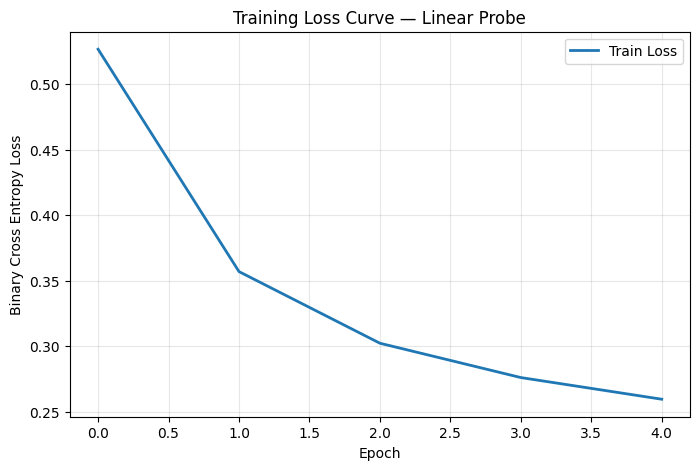

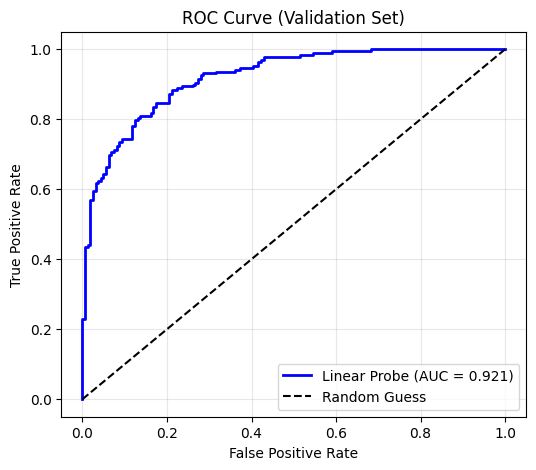

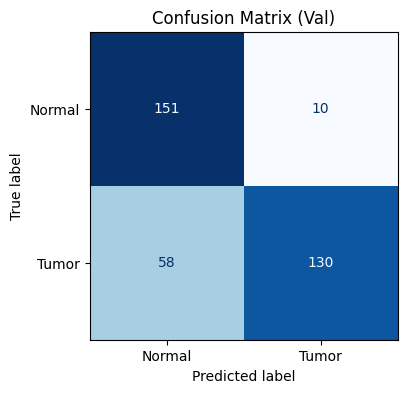

Running PCA on extracted 512D ResNet features...


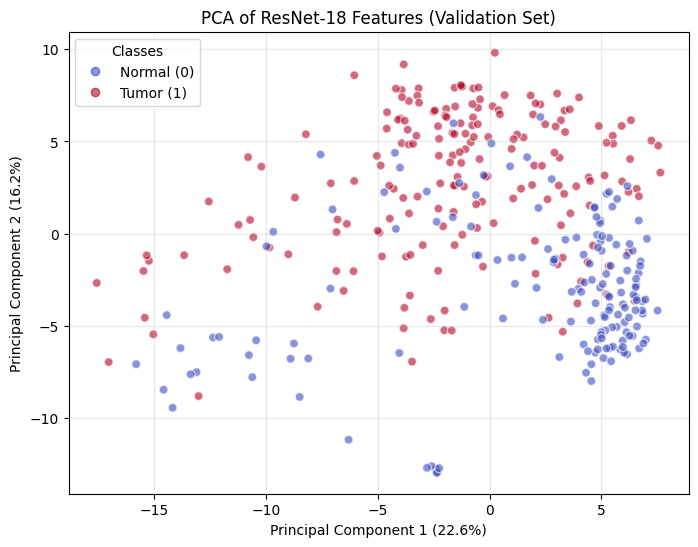

In [44]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA

# Evaluate Metrics on Validation Set
print("--- Linear Probe Evaluation ---")
val_metrics = evaluate_model(model, val_loader)
print(f"ID (Val) AUC-ROC: {val_metrics['auc_roc']:.4f}\n")

# Plot Training History (Loss Curves)
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss", linewidth=2)
if len(history["val_loss"]) > 0:
    plt.plot(history["val_loss"], label="Validation Loss", linewidth=2, linestyle="--")
plt.title("Training Loss Curve — Linear Probe")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Helper Function to get raw probabilities
def get_preds_probe(eval_model, dataloader):
    eval_model.eval()
    all_labels, all_probs = [], []
    with torch.no_grad():
        for batch in dataloader:
            # TensorDataset yields only features and labels
            features, labels = batch[0], batch[1]
            outputs = eval_model(features.to(DEVICE))
            probs = torch.sigmoid(outputs).cpu().numpy().flatten()
            all_probs.extend(probs)
            all_labels.extend(labels.numpy().flatten())
    return np.array(all_labels), np.array(all_probs)

y_true_val, probs_val = get_preds_probe(model, val_loader)

# ROC Curve & Confusion Matrix
# Plot ROC Curve
plt.figure(figsize=(6, 5))
fpr, tpr, _ = roc_curve(y_true_val, probs_val)
plt.plot(fpr, tpr, label=f"Linear Probe (AUC = {auc(fpr, tpr):.3f})", color="blue", linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.title("ROC Curve (Validation Set)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot Confusion Matrix (Threshold = 0.5)
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_true_val, (probs_val > 0.5).astype(int))
disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Tumor"])
disp.plot(cmap="Blues", colorbar=False, ax=plt.gca())
plt.title("Confusion Matrix (Val)")
plt.show()

# Visualize ResNet Learned Representations (PCA)
# We grab the raw 512-dimensional features directly from the Validation TensorDataset.
# Subsampling to 2000 points so the scatter plot remains readable.
subset_size = min(2000, len(resnet_val_dataset))
X_features = resnet_val_dataset.tensors[0][:subset_size].numpy()
y_labels = resnet_val_dataset.tensors[1][:subset_size].numpy().flatten()

print("Running PCA on extracted 512D ResNet features...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_features)

plt.figure(figsize=(8, 6))

# Plot points, coloring by label (0 = Normal, 1 = Tumor)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_labels, cmap='coolwarm', alpha=0.6, edgecolors='w', s=40)

plt.title("PCA of ResNet-18 Features (Validation Set)")
plt.xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")

# Add a clean legend
handles, _ = scatter.legend_elements()
plt.legend(handles, ["Normal (0)", "Tumor (1)"], title="Classes")
plt.grid(True, alpha=0.3)
plt.show()

### Design justification

> **Question.** (1.0 pts)
>
> Why changing only the last layer of the pretrained ResNet-18 is a reasonable baseline for this dataset?
>   
> Explain what were the metrics that you used to test the hypothesis and why they help answering the question.

Substituir apenas a última camada do ResNet-18 (usando um Linear Probe) é uma baseline razoável porque nos permite testar se os padrões visuais fundamentais que o modelo já aprendeu no ImageNet (como bordas, formas e texturas básicas) são transferíveis para o domínio da histopatologia. Ao congelar a rede e treinar apenas essa camada final, conseguimos avaliar a capacidade desse modelo produzir representações que de fato ilustram o comportamento das imagens. Para validar se essas representações realmente funcionam, utilizamos a Acurácia e, principalmente, a ROC-AUC. Como as classes estão equilibradas, a Acurácia nos dá uma noção direta de acertos, mas a AUC-ROC mede a capacidade real e robusta do modelo de separar tumores de tecidos saudáveis. É justamente o gap dessas métricas entre o conjunto ID e o OOD que responde à nossa pergunta: se a performance se mantiver alta no hospital novo, provamos a hipótese de que o modelo generalizou as características do câncer; se despencar, sabemos que ele apenas memorizou "atalhos" visuais, como o estilo de coloração do hospital de treino.

### Discussion

> **Question.** (1.0 pts)
>
> Discuss the results of using a frozen backbone. Address the following points:
>
> Do the results support or contradict the hypothesis? Refer to specific numbers.
>
> What does the gap between metrics ID vs OOD imply about the representations?
>
> What limitations does the linear probe evaluation have when assessing the quality of the pretrained representations?
> Can we correctly attribute what is causing the observed performance?

TODO

---

## Experiment 2: Is the CNN Structure Necessary?

ResNet is a convolutional architecture, meaning it builds in several strong assumptions:
- local feature detection via small kernels
- spatial weight sharing
- hierarchical composition of features

These are not universal truths about image data, they are inductive biases that may or may not be useful for a given task.

A model with no spatial inductive bias, such as a multilayer perceptron (MLP) applied to flattened pixels, treats every pixel independently and must learn spatial relationships from data alone.
Comparing the two isolates the contribution of the convolutional inductive bias from all other factors.

This comparison also illustrates a central theme of this assignment: **raw parameter count does not determine generalization**.
As you will see, the MLP on 96×96×3 input has a first hidden layer alone with more parameters than the entire CNN, yet it may perform worse, demonstrating that inductive alignment with the data structure matters more than model capacity.

Note that, as we changed a lot of things when compared with the previous experiment, we cannot make a direct comparison, but we can see the performance on a baseline that already solves the problem.

> **Question:** Does the spatial inductive bias of a convolutional architecture improve generalization over a non-spatial model with comparable or greater parameter count?

### Hypothesis

> **Hypothesis.** (1.0 pts)
>
> *State a falsifiable hypothesis. Your hypothesis should make a concrete, directional prediction about the ID accuracy, OOD accuracy, and/or ID–OOD gap for the MLP vs SmallCNN. Refer to specific structural properties you expect to matter.*



Nossa hipótese é que a CNN alcançará uma acurácia maior tanto no conjunto ID quanto no OOD, além de apresentar um gap ID-OOD menor, quando comparada ao modelo MLP. Isso deve ocorrer porque os vieses indutivos espaciais da arquitetura convolucional permitem que a rede extraia as estruturas morfológicas dos tecidos (como a densidade dos núcleos tumorais) independentemente da posição exata em que aparecem na imagem. Em contrapartida, como o MLP trata cada pixel de forma independente e não possui qualquer noção de vizinhança ou estrutura espacial, ele provavelmente usará sua grande quantidade de parâmetros para memorizar o conjunto de treino, resultando em um overfitting que vai derrubar sua capacidade de generalização para hospitais não vistos (OOD).

In [ ]:
class MLP(nn.Module):
    """Fully connected network."""

    def __init__(self, input_size: int, hidden_dims: list[int], dropout: float = 0.3) -> None:
        super().__init__()
        layers = []
        prev_dim = input_size
        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 1))  # saída binária (1 logit)
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.view(x.size(0), -1)  # flatten (batch, C, H, W) -> (batch, C*H*W)
        return self.net(x)


class SmallCNN(nn.Module):
    """Small convolutional network, spatial inductive bias."""

    def __init__(self, dropout: float = 0.3) -> None:
        super().__init__()
        # Small CNN with the following structure:
        #   3 convolutional blocks, each: Conv2d → BatchNorm2d → Activation → MaxPool2d(2)
        #   Choose any activation function you want (e.g., ReLU, LeakyReLU, GELU).
        #   The channel widths can be of your choice, but we recommend something like 3 → 32 → 64 → 128.
        #   The last block should be followed by: AdaptiveAvgPool2d(1) → Flatten → Linear.
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(128, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        return self.fc(x)

In [29]:
# For this experiment, you can change the data transforms if you want.
# We recommend using smaller input sizes (e.g., the raw data is 96×96)
# for the MLP and SmallCNN, since they have fewer parameters than the ResNet-18
# and will overfit more easily on the full 224×224 images.
# You can use the same normalization as before, or recompute the mean and std
# on the smaller input size.

SIZE = 96

transform = transforms.Compose(
    [
        # You can uncomment the line below if you want to use a different input size.
        # transforms.Resize((SIZE, SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

train_data = dataset.get_subset("train", transform=transform)
val_data = dataset.get_subset("val", transform=transform)
test_data = dataset.get_subset("test", transform=transform)


train_loader = get_train_loader("standard", train_data, batch_size=128, num_workers=4)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False, num_workers=4)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False, num_workers=4)

In [ ]:
mlp_input_dim = SIZE * SIZE * 3  # 96 × 96 × 3 = 27,648

mlp = MLP(input_size=mlp_input_dim, hidden_dims=[512, 256]).to(DEVICE)
cnn = SmallCNN().to(DEVICE)

def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

learning_rate = 1e-3
n_epochs = 1
dropout = 0.3  # já embutido nas classes acima

mlp_optimizer = optim.Adam(mlp.parameters(), lr=learning_rate)
mlp_criterion = nn.BCEWithLogitsLoss()
train_mlp_history = train_model(mlp, train_loader, mlp_criterion, mlp_optimizer, n_epochs=n_epochs)

KeyboardInterrupt: 

In [ ]:
torch.save(mlp.state_dict(), "exp2.1_mlp.pt")
print("Saved: exp2.1_mlp.pt")

In [ ]:
cnn_optimizer = optim.Adam(cnn.parameters(), lr=learning_rate)
cnn_criterion = nn.BCEWithLogitsLoss()
train_cnn_history = train_model(cnn, train_loader, cnn_criterion, cnn_optimizer, n_epochs=n_epochs)


print(f"MLP total parameters : {count_params(mlp):>12,}")
print(f"CNN total parameters : {count_params(cnn):>12,}")
print()
print("Note: both models receive the same 96×96×3 input and the same training procedure.")

In [ ]:
torch.save(cnn.state_dict(), "exp2.1_cnn.pt")
print("Saved: exp2.1_cnn.pt")

In [ ]:
print(DEVICE)
torch.cuda.is_available()

cuda


True

In [ ]:
mlp = MLP(input_size=mlp_input_dim, hidden_dims=[512, 256]).to(DEVICE)
cnn = SmallCNN().to(DEVICE)

mlp_optimizer = optim.Adam(mlp.parameters(), lr=learning_rate)
mlp_criterion = nn.BCEWithLogitsLoss()
train_mlp_history = train_model(mlp, train_loader, mlp_criterion, mlp_optimizer, n_epochs=n_epochs)



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 1/5 — Train Loss: 0.5407, Train Acc: 0.7506                   
Epoch 2/5 — Train Loss: 0.4802, Train Acc: 0.7804                   


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c6ae3304360>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
Exception ignored in:     self._shutdown_workers()<function _MultiProcessingDataLoaderIter.__del__ at 0x7c6ae3304360>

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    if w.is_alive():    
self._shutdown_workers() 
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
     if w.is_alive(): 
        ^ ^ ^^ ^^^^^^^^^^^^^^^^^^^^

  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._par

^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c6ae3304360>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
     if w.is_alive():
      ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^

^^^^^^
^AssertionError: can only test a child process


Epoch 3/5 — Train Loss: 0.4437, Train Acc: 0.8034                   
Epoch 4/5 — Train Loss: 0.4221, Train Acc: 0.8129                   


In [ ]:
torch.save(mlp.state_dict(), "exp2.2_mlp.pt")
print("Saved: exp2.2_mlp.pt")

In [ ]:
cnn_optimizer = optim.Adam(cnn.parameters(), lr=learning_rate)
cnn_criterion = nn.BCEWithLogitsLoss()
train_cnn_history = train_model(cnn, train_loader, cnn_criterion, cnn_optimizer, n_epochs=n_epochs)

print(f"MLP total parameters : {count_params(mlp):>12,}")
print(f"CNN total parameters : {count_params(cnn):>12,}")

In [ ]:
torch.save(mlp.state_dict(), "exp2.2_cnn.pt")
print("Saved: exp2.2_cnn.pt")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
import torch

# Evaluate Metrics on Train and Val Sets
print("--- MLP Evaluation ---")
mlp_train_metrics = evaluate_model(mlp, train_loader)
mlp_val_metrics = evaluate_model(mlp, val_loader)
print(f"Train AUC-ROC: {mlp_train_metrics['auc_roc']:.4f}")
print(f"Val   AUC-ROC: {mlp_val_metrics['auc_roc']:.4f}\n")

print("--- CNN Evaluation ---")
cnn_train_metrics = evaluate_model(cnn, train_loader)
cnn_val_metrics = evaluate_model(cnn, val_loader)
print(f"Train AUC-ROC: {cnn_train_metrics['auc_roc']:.4f}")
print(f"Val   AUC-ROC: {cnn_val_metrics['auc_roc']:.4f}\n")

# Plot Training History (Loss Curves)
plt.figure(figsize=(8, 5))
plt.plot(train_mlp_history["train_loss"], label="MLP Loss", linestyle="--")
plt.plot(train_cnn_history["train_loss"], label="CNN Loss", linewidth=2)
plt.title("Training Loss Comparison: MLP vs SmallCNN")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Helper Function to get raw probabilities
def get_preds(model, dataloader):
    model.eval()
    all_labels, all_probs = [], []
    with torch.no_grad():
        for images, labels, *_ in dataloader:
            outputs = model(images.to(DEVICE))
            probs = torch.sigmoid(outputs).cpu().numpy().flatten()
            all_probs.extend(probs)
            all_labels.extend(labels.numpy().flatten())
    return np.array(all_labels), np.array(all_probs)

# Get predictions for Validation Set only
y_true_val, mlp_probs_val = get_preds(mlp, val_loader)
_, cnn_probs_val = get_preds(cnn, val_loader)

# ROC Curves & Confusion Matrices
# Plot ROC Curve
plt.figure(figsize=(8, 6))
fpr_mlp, tpr_mlp, _ = roc_curve(y_true_val, mlp_probs_val)
fpr_cnn, tpr_cnn, _ = roc_curve(y_true_val, cnn_probs_val)

plt.plot(fpr_mlp, tpr_mlp, label=f"MLP (AUC = {auc(fpr_mlp, tpr_mlp):.3f})")
plt.plot(fpr_cnn, tpr_cnn, label=f"CNN (AUC = {auc(fpr_cnn, tpr_cnn):.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.title("ROC Curves (Validation Set)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot Confusion Matrices (Threshold = 0.5)
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

cm_mlp = confusion_matrix(y_true_val, (mlp_probs_val > 0.5).astype(int))
ConfusionMatrixDisplay(cm_mlp, display_labels=["Normal", "Tumor"]).plot(ax=axs[0], cmap="Blues", colorbar=False)
axs[0].set_title("MLP Confusion Matrix (Val)")

cm_cnn = confusion_matrix(y_true_val, (cnn_probs_val > 0.5).astype(int))
ConfusionMatrixDisplay(cm_cnn, display_labels=["Normal", "Tumor"]).plot(ax=axs[1], cmap="Oranges", colorbar=False)
axs[1].set_title("CNN Confusion Matrix (Val)")

plt.tight_layout()
plt.show()

# Visualize Learned Representations (Weights/Filters)
# A helper to normalize image data for plotting
def normalize_image(img_tensor):
    img = img_tensor - img_tensor.min()
    img = img / (img.max() + 1e-8)
    return img

# Visualize CNN First Layer Filters
# The first layer has 32 filters, each looking at 3 channels (RGB) with a 3x3 kernel
cnn_weights = cnn.features[0].weight.data.cpu()
fig, axs = plt.subplots(4, 8, figsize=(12, 6))
fig.suptitle("SmallCNN: First Layer Filters (3x3 spatial bias)", fontsize=14)

for i, ax in enumerate(axs.flatten()):
    if i < 32:
        # PyTorch shape is [Out, In, H, W]. Matplotlib wants [H, W, Channels]
        filter_img = cnn_weights[i].permute(1, 2, 0)
        ax.imshow(normalize_image(filter_img))
    ax.axis('off')
plt.show()

# Visualize MLP First Layer Weights
# The MLP first layer has 512 neurons, each looking at 27,648 pixels
mlp_weights = mlp.net[0].weight.data.cpu()
fig, axs = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("MLP: First 16 Hidden Neurons Reshaped to 96x96 (No spatial bias)", fontsize=14)

for i, ax in enumerate(axs.flatten()):
    # Extract the weights for one neuron and reshape back to [Channels, Height, Width]
    neuron_weights = mlp_weights[i].view(3, 96, 96)
    # Convert to [Height, Width, Channels] for Matplotlib
    neuron_img = neuron_weights.permute(1, 2, 0)
    ax.imshow(normalize_image(neuron_img))
    ax.axis('off')
plt.show()

### Design justification

> **Question.** (1.0 pts)
>
> Why comparing MLP vs SmallCNN (both trained from scratch on the same data) isolates the contribution of the convolutional inductive bias?
>
> What aspect of the your implementation makes it an atomic ablation?

Comparar o MLP com a SmallCNN (ambos treinados do zero e nos mesmos dados) isola o viés indutivo convolucional porque tira qualquer conhecimento prévio, como os pesos do ImageNet que tínhamos no ResNet. A diferença fundamental entre os dois é a forma como enxergam a imagem: o MLP "achata" a matriz de pixels e trata cada cor de forma isolada, sem saber se um pixel está do lado do outro; já a CNN usa filtros para processar pequenas regiões locais, assumindo que a vizinhança espacial dos pixels importa para achar padrões. Como os dois partem do zero para aprender a mesma tarefa, qualquer diferença no resultado final reflete o impacto de ter ou não essa noção de espaço (o viés indutivo).

O que torna a nossa implementação uma "ablação atômica" (ou seja, isolar uma única variável por vez) é que nós travamos todas as outras variáveis do experimento. No código, garantimos que os dois modelos recebam a imagem com a mesma resolução reduzida (96×96×3), sofram os mesmos transforms, e passem pela mesma função de treinamento (train_model). Ambos usam a mesma função de perda (BCEWithLogitsLoss), o mesmo otimizador (Adam) e a mesma taxa de aprendizado (1e−3). A única peça que foi trocada foi o interior da rede (camadas lineares vs. blocos convolucionais), o que garante que os resultados obtidos sejam reflexo exclusivo da diferença arquitetural e não de alguma vantagem no processo de treino.

### Discussion

> **Question.** (1.0 pts)
>
> Discuss the results of using MLP vs CNN in generalization. Address the following points:
>
> Do the results support or contradict your hypothesis? Refer to specific metric values.
>
> Compare the ID–OOD gap for MLP vs CNN. Which model generalizes better to the unseen center, and why might that be?
>
> The MLP has more parameters than the CNN, did this fact influenced the generalization aspect of the MLP?
>
> How do the from-scratch models compare to the frozen ResNet from Experiment 1?

*YOUR ANSWER HERE*

---

## Experiment 3: Are Colors a Required Feature?

A potential issue in the data is that, different hospitals use different techniques for collecting data.
One example of such change is how the stain intensity shift across hospital centers.

Because each center has a different scanner and staining protocol, the color distribution of a patch partially encodes which hospital it came from.
This creates a potential **spurious correlation**: a model trained on centers 0–2 may learn to use color as a predictive cue, even though color is determined by the imaging center rather than by tumor status.

Under center shift (training on centers 0–2, testing on center 4), a model that relies on color will encounter a new color distribution and may fail even if the morphological signal is present.

> **Question:** Does the previous CNN rely on color information to predict tumor status, and does removing color change the generalizaion gap?

### Hypothesis

> **Hypothesis.** (1.0 pts)
>
> *State a falsifiable hypothesis. Your hypothesis should predict the direction of the change in ID accuracy, OOD accuracy, and/or ID–OOD gap when switching from RGB to grayscale input. Relate your prediction to the color distribution visualization from the Data Exploration section.*

Nossa hipótese é que, ao treinarmos a SmallCNN usando imagens em escala de cinza em vez de RGB, observaremos uma redução considerável no gap de performance entre os conjuntos ID (treino) e OOD (que aqui estamos considerando como a validação). Como notamos nos gráficos de distribuição RGB na etapa de exploração de dados, cada hospital possui um perfil de coloração muito distinto devido aos seus próprios protocolos de escaneamento, o que provavelmente fez o modelo anterior usar essas cores como "atalhos" (uma correlação espúria) para decorar a origem da imagem em vez de focar apenas na morfologia do tecido. Ao removermos totalmente a informação de cor, prevejo que a acurácia no conjunto ID pode até sofrer uma leve queda, pois o modelo perde esse atalho fácil do ambiente de treino, mas a acurácia no conjunto OOD se tornará mais resiliente, resultando no estreitamento do gap. Isso ocorrerá porque o modelo será forçado a basear suas previsões exclusivamente em características estruturais, como a densidade e a forma dos núcleos celulares, que são marcadores reais do tumor, independentemente do hospital de onde a amostra veio.

In [ ]:
# Maintain the same configurations you set on the previous cells (e.g. input size, normalization, etc.) to
# isolate the effect of changing the data assumptions.

transform = transforms.Compose(
    [
        # Uncomment the line below if you want to use a different input size.
        # transforms.Resize((SIZE, SIZE)),
        transforms.Grayscale(num_output_channels=3),  # Convert to 3-channel grayscale to use the same architecture as before.
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ]
)

train_data = dataset.get_subset("train", transform=transform)
val_data = dataset.get_subset("val", transform=transform)
test_data = dataset.get_subset("test", transform=transform)

In [ ]:
# Your code here
# Train, evaluate and analyze.

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# Inicialização do Modelo, Otimizador e Loss
print("Inicializando SmallCNN para o Experimento Grayscale (Escala de Cinza)...")
cnn_gray = SmallCNN().to(DEVICE)
optimizer_gray = optim.Adam(cnn_gray.parameters(), lr=1e-3)
criterion_gray = nn.BCEWithLogitsLoss()

# Treinamento
n_epochs = 5 
train_gray_history = train_model(cnn_gray, train_loader, criterion_gray, optimizer_gray, n_epochs=n_epochs)

# Avaliação das Métricas (ID vs OOD)
print("\n--- Avaliação da SmallCNN (Grayscale) ---")
gray_train_metrics = evaluate_model(cnn_gray, train_loader)
gray_val_metrics = evaluate_model(cnn_gray, val_loader)

print(f"ID  (Treino)  AUC-ROC: {gray_train_metrics['auc_roc']:.4f}")
print(f"OOD (Val)     AUC-ROC: {gray_val_metrics['auc_roc']:.4f}")
# O gap mostrará numericamente se a hipótese está correta
print(f"ID-OOD Gap:   {gray_train_metrics['auc_roc'] - gray_val_metrics['auc_roc']:.4f}\n")

In [ ]:
torch.save(cnn_gray.state_dict(), "exp3_cnn_gray.pt")
print("Saved: exp3_cnn_gray.pt")

In [ ]:
# Visualizações e Análise

# Curva de Loss
plt.figure(figsize=(6, 4))
plt.plot(train_gray_history["train_loss"], label="Train Loss (Grayscale)", linewidth=2, color="purple")
plt.title("Curva de Loss: SmallCNN Sem Cor")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Extraindo as probabilidades para os gráficos seguintes
y_true_train, gray_probs_train = get_preds(cnn_gray, train_loader)
y_true_val, gray_probs_val = get_preds(cnn_gray, val_loader)

# Curvas ROC
plt.figure(figsize=(8, 6))
fpr_train, tpr_train, _ = roc_curve(y_true_train, gray_probs_train)
fpr_val, tpr_val, _ = roc_curve(y_true_val, gray_probs_val)

plt.plot(fpr_train, tpr_train, label=f"ID Treino (AUC = {auc(fpr_train, tpr_train):.3f})", linestyle="--")
plt.plot(fpr_val, tpr_val, label=f"OOD Validação (AUC = {auc(fpr_val, tpr_val):.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label="Chute Aleatório")
plt.title("Curvas ROC: Comparação ID vs OOD (Sem Cor)")
plt.xlabel("Taxa de Falso Positivo")
plt.ylabel("Taxa de Verdadeiro Positivo")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Matrizes de Confusão (Limiar = 0.5)
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

cm_train = confusion_matrix(y_true_train, (gray_probs_train > 0.5).astype(int))
ConfusionMatrixDisplay(cm_train, display_labels=["Normal", "Tumor"]).plot(ax=axs[0], cmap="Purples", colorbar=False)
axs[0].set_title("Matriz de Confusão: ID (Treino)")

cm_val = confusion_matrix(y_true_val, (gray_probs_val > 0.5).astype(int))
ConfusionMatrixDisplay(cm_val, display_labels=["Normal", "Tumor"]).plot(ax=axs[1], cmap="Purples", colorbar=False)
axs[1].set_title("Matriz de Confusão: OOD (Validação)")

plt.tight_layout()
plt.show()

# Visualização dos Filtros
cnn_gray_weights = cnn_gray.features[0].weight.data.cpu()
fig, axs = plt.subplots(4, 8, figsize=(12, 6))
fig.suptitle("SmallCNN (Grayscale): Filtros da 1ª Camada (Focando em Estrutura)", fontsize=14)

for i, ax in enumerate(axs.flatten()):
    if i < 32:
        # Pega a imagem do filtro e ajusta para o matplotlib
        filter_img = cnn_gray_weights[i].permute(1, 2, 0)
        # Normalização simples para exibir o filtro
        filter_img = filter_img - filter_img.min()
        filter_img = filter_img / (filter_img.max() + 1e-8)
        ax.imshow(filter_img)
    ax.axis('off')
plt.show()

### Design justification

> **Question.** (1.0 pts)
>
> Explain your experiment configuration, state what remained the same from the previous experiment, and what have changed.
>
> How does your experiment answer the question?

Neste experimento, a nossa configuração foi pensada para isolar ao máximo a variável cor. Para isso, mantivemos a mesma arquitetura do modelo (a SmallCNN), o mesmo otimizador (Adam com taxa de aprendizado de 1e−3), a mesma função de custo (BCEWithLogitsLoss), o mesmo número de épocas e o mesmo tamanho de resolução das imagens (96×96). A única mudança que fizemos foi nos dados de entrada: adicionamos o transforms.Grayscale(num_output_channels=3) no pipeline do dataset. Usar num_output_channels=3 foi um detalhe importante, pois transformou a imagem para escala de cinza copiando o mesmo valor para os três canais. Isso nos permitiu reutilizar a SmallCNN original sem precisar reescrever a primeira camada convolucional, que esperava receber 3 canais.

Esse experimento responde à nossa pergunta porque funciona como uma ablação. Como a arquitetura e o processo de aprendizado são idênticos aos do Experimento 2, qualquer diferença no resultado final só pode ser atribuída à ausência de cor. Se a CNN original estava usando os tons de rosa e roxo (que variam de hospital para hospital) como um "atalho" para decorar o conjunto de treino (o que chamamos de correlação espúria), a remoção da cor obriga o modelo a abandonar esse atalho. Portanto, ao compararmos o gap de performance (ID vs OOD) do modelo RGB com este modelo em escala de cinza, conseguimos provar se a cor era a muleta da rede: se o gap diminuir agora, significa que a cor estava atrapalhando a generalização e que focar puramente nas estruturas e formas morfológicas das células é o melhor caminho.

### Discussion

> **Question.** (1.0 pts)
>
> Discuss the results of removing the color feature. Address the following points:
>
> Does removing color improve or degrade ID metrics? OOD metrics? Was this consistent with your hypothesis?
>
> Can we attribute the results uniquely to the color change?
>
> How does it connect with the Data exploration you conducted?

*YOUR ANSWER HERE*

---

## Model Selection: Choosing the final model

The three previous experiments provide evidence about what drives and what hinders generalization in this setting:

- **Experiment 1** established the baseline: a linear probe on frozen pretrained features achieves some performance, with a measurable ID–OOD gap.
- **Experiment 2** assessed whether spatial inductive bias matters.
- **Experiment 3** assessed whether color is a spurious or informative feature.

In this experiment you will use those observations to motivate a final model of your choice and test whether it generalizes for the test dataset.

You don't need to state a hypothesis, or justify your design here.
Experiment with different settings and suppositions until you converge with the best model that might well generalize.
You can use ResNet, or a network from scratch, just report the number of parameters on the final model and the time it took to
train.

> **Question**
>
> Based on the evidence from previous experiments, propose a deep neural network that might reduce the ID–OOD generalization gap.

In [ ]:
# TODO: Implement your final model (you can choose any architecture you want, including the ones you implemented before) and train it on the dataset.
# Some suggestions:
# - You can use the ResNet-18 backbone from Experiment 1 and fine-tune all (or the last N) layers instead of freezing them.
# - You can use the MLP or SmallCNN from Experiment 2 and increase their capacity (e.g., more layers, more hidden units, etc.).
# - You can change the data transforms (e.g., input size, normalization, data augmentation, etc.) to see if it improves the performance of the models.
# - You can use other loss functions (e.g., focal loss, dice loss, etc.) or optimization algorithms (e.g., AdamW, RMSProp, etc.).
# - A combination of the above suggestions (caution to not change too many things at once, or it will be harder to analyze the results and understand what caused the performance changes).

In [ ]:
# Evaluate your final model, analyze the results.
# Use the same evaluation metrics and plots you used in the previous experiments to analyze the performance of your final model.
# Now, you can also evaluate your final model on the test set, but make sure to only do this after you have finalized your model
# and analysis based on the validation set, to avoid overfitting to the test set.

### Discussion

> **Question.** (1.0 pts)
>
> Discuss the results for your final model.
>
> What is the number of parameters of your model? Compare it with the size of the previous models and draw a link with the results.
>
> What was the training time? Did it take more or less time than the expected?
>
> How does the OOD performance connect with your changes in the data and model?
>
> If your results are positive, can you attribute for certain which aspect of your model mostly contributed for the increase in performance?
>
> Conversely, if your results are negative (the modification were worse than the experiments), provide an alternative explanation that is consistent with the failure.

*YOUR ANSWER HERE*

---

## Assignment Submission

This notebook must be filled with your solution and submitted on the Assignment's entry at our Google Classroom page.

Before submitting, verify that:
- The notebook runs end-to-end without errors (use **Run All** after restarting the kernel).
- All plots are rendered in the output.
- All written section (Hypothesis, Design, Discussion) are filled in.
- AI usage declaration and prompts are included, if applicable.

**Important: Only one member of the group should submit.**

### Policy for late submissions

You are NOT encouraged to submit after the deadline; however, in this case the following penalties apply:

- 25% deduction for 1-day late submission.
- 50% deduction for 2-day late submission.
- 75% deduction for 3-day late submission.